# Lungcap Project 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("lungCapData.csv")
df.head()


,LungCap,Age,Height,Smoke,Gender,Caesarean
0,6.475,6,62.1,no,male,no
1,10.125,18,74.7,yes,female,no
2,9.550,16,69.7,no,female,yes
3,11.125,14,71.0,no,male,no
4,4.800,5,56.9,no,male,no


In [2]:
df.shape

(725, 6)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 725 entries, 0 to 724
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LungCap    725 non-null    float64
 1   Age        725 non-null    int64  
 2   Height     725 non-null    float64
 3   Smoke      725 non-null    object 
 4   Gender     725 non-null    object 
 5   Caesarean  725 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 34.1+ KB


In [4]:
df.isnull().sum()

LungCap      0
Age          0
Height       0
Smoke        0
Gender       0
Caesarean    0
dtype: int64

In [5]:
#Data Cleaning and Encoding

df['Smoke'] = df['Smoke'].map({'yes':1, 'no':0})
df['Gender'] = df['Gender'].map({'male':1, 'female':0})
df['Caesarean'] = df['Caesarean'].map({'yes':1, 'no':0})

df.head()


,LungCap,Age,Height,Smoke,Gender,Caesarean
0,6.475,6,62.1,0,1,0
1,10.125,18,74.7,1,0,0
2,9.550,16,69.7,0,0,1
3,11.125,14,71.0,0,1,0
4,4.800,5,56.9,0,1,0


# EDA

In [6]:
df.describe()


,LungCap,Age,Height,Smoke,Gender,Caesarean
count,725.000000,725.000000,725.000000,725.000000,725.000000,725.000000
mean,7.863148,12.326897,64.836276,0.106207,0.506207,0.226207
std,2.662008,4.004750,7.202144,0.308315,0.500307,0.418663
min,0.507000,3.000000,45.300000,0.000000,0.000000,0.000000
25%,6.150000,9.000000,59.900000,0.000000,0.000000,0.000000
50%,8.000000,13.000000,65.400000,0.000000,1.000000,0.000000
75%,9.800000,15.000000,70.300000,0.000000,1.000000,0.000000
max,14.675000,19.000000,81.800000,1.000000,1.000000,1.000000


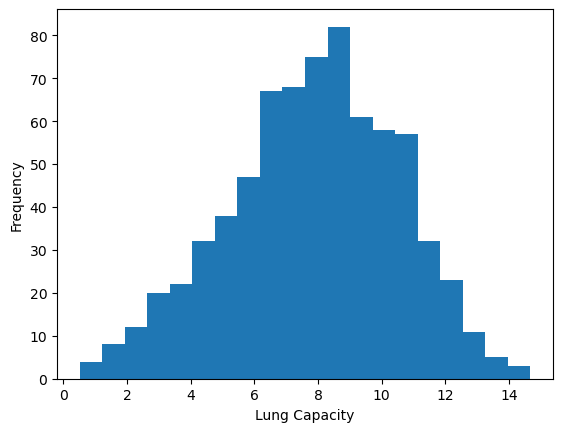

In [7]:
#LungCap vs Frequency

plt.hist(df['LungCap'], bins=20)
plt.xlabel("Lung Capacity")
plt.ylabel("Frequency")
plt.show()


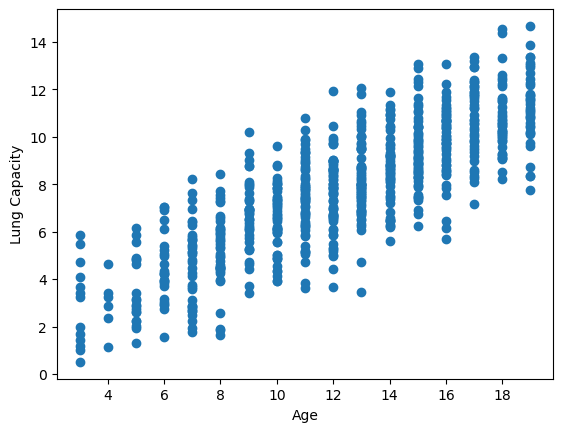

In [8]:
# LungCap vs Age

plt.scatter(df['Age'], df['LungCap'])
plt.xlabel("Age")
plt.ylabel("Lung Capacity")
plt.show()


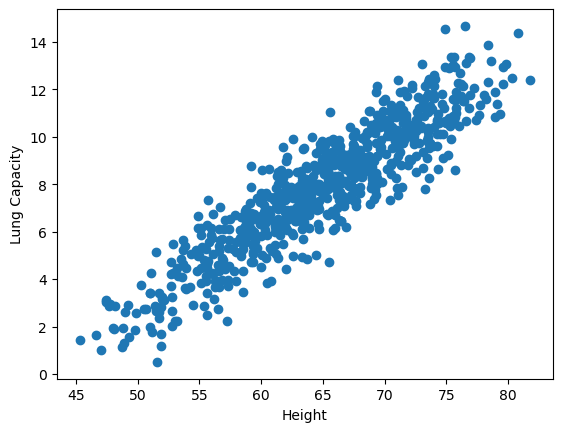

In [9]:
# LungCap vs Height

plt.scatter(df['Height'], df['LungCap'])
plt.xlabel("Height")
plt.ylabel("Lung Capacity")
plt.show()


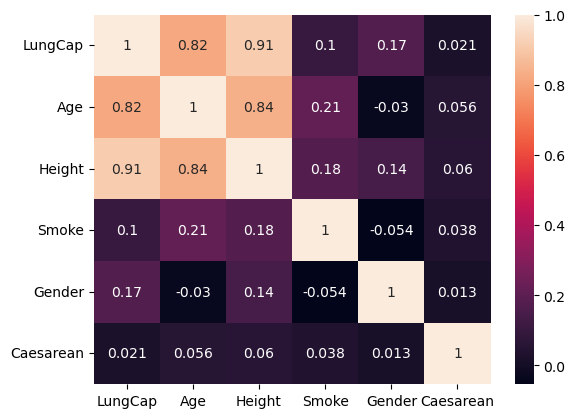

In [10]:
#Corelation Analysis 
#Heatmap

sns.heatmap(df.corr(), annot=True)
plt.show()


# Model Building

# Linear Regression

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error 

X = df.drop('LungCap', axis=1)
y = df['LungCap']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [12]:
y_pred_lr = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

R2 Score: 0.8381802829214935
MAE: 0.8457002224968185


In [13]:
lr_mape = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
print("MAPE:", lr_mape)

MAPE: 11.91237553495944


In [14]:
Lr_Accuracy = 100-lr_mape
Lr_Accuracy

np.float64(88.08762446504056)

# Decision Tree Regressor

In [15]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

In [18]:
y_pred_dt = dt_model.predict(X_test)
y_pred_dt

array([ 8.85 ,  9.15 ,  8.225,  6.7  ,  7.275,  8.9  ,  7.825,  3.175,
        3.975,  8.725, 11.075,  3.425,  6.15 ,  6.225,  1.325,  3.625,
        6.075,  5.5  ,  8.025,  5.55 ,  9.625, 11.775,  8.1  , 12.125,
        5.875,  6.7  ,  6.15 ,  3.425,  8.975, 14.675, 12.5  , 10.7  ,
        9.925,  8.7  , 10.475,  7.225,  8.   ,  1.85 ,  7.925,  6.7  ,
       10.4  ,  1.775,  4.625, 11.075,  8.1  ,  3.175,  7.825,  8.35 ,
        6.525,  5.85 ,  6.175, 12.15 ,  7.55 ,  6.45 ,  3.625, 12.375,
       11.875,  8.625, 12.125,  9.025,  5.325, 10.875,  6.7  ,  6.725,
        6.125,  6.05 , 11.75 ,  2.875, 10.725,  7.625,  3.6  , 11.575,
       11.525,  9.65 ,  7.7  ,  4.425,  7.65 ,  4.475,  6.45 ,  5.05 ,
        8.475, 10.825,  5.55 , 10.25 , 10.925,  6.425,  7.625,  2.025,
        8.1  , 10.475, 12.9  , 11.875,  9.375,  6.25 ,  7.1  ,  7.675,
        5.775,  7.175,  4.625,  1.95 ,  6.45 ,  5.475,  5.15 ,  8.775,
        2.925,  6.7  ,  9.625,  9.725,  6.825, 10.35 ,  8.6  ,  5.55 ,
      

In [19]:
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100
print("R2 Score:", r2_dt)
print("MAE:", mae_dt)
print("MAPE:", mape_dt)

R2 Score: 0.6976931832399214
MAE: 1.1456896551724138
MAPE: 16.27167190355592


In [20]:
dt_Accuracy= 100 - mape_dt

dt_Accuracy

np.float64(83.72832809644407)

# Random Forest

In [21]:
from sklearn.ensemble import RandomForestRegressor

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [23]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [24]:
y_pred_rf = rf_model.predict(X_test)


In [25]:
r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
RF_mape = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print("R2 Score :", r2)
print("MAE      :", mae)
print("MAPE (%) :", RF_mape)

R2 Score : 0.8025536095131471
MAE      : 0.8870211190476186
MAPE (%) : 12.532374887387496


In [26]:
RF_Accuracy= 100 - RF_mape
RF_Accuracy

np.float64(87.46762511261251)

In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5],
}

grid = GridSearchCV(XGBRegressor(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

best_xgb = grid.best_estimator_

pred = best_xgb.predict(X_test)

print("Tuned XGBoost R2:", r2_score(y_test, pred))


xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)
XG_mape = np.mean(np.abs((y_test - pred_xgb) / y_test)) * 100

print("XGBoost R2:", r2_score(y_test, pred_xgb))

Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Tuned XGBoost R2: 0.8288338944363872
XGBoost R2: 0.8178120671191003


In [28]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr = SVR(C=10, kernel='rbf')

svr.fit(X_train_scaled, y_train)

pred_svr = svr.predict(X_test_scaled)
svm_mape = np.mean(np.abs((y_test - pred_svr) / y_test)) * 100


print("SVR R2:", r2_score(y_test, pred_svr))

SVR R2: 0.8122249431263742


In [29]:
from sklearn.metrics import r2_score

# Accuracy = R2 Score * 100

accuracy_lr = Lr_Accuracy = 100-lr_mape
accuracy_dt = dt_Accuracy
accuracy_rf = RF_Accuracy= 100 - RF_mape
accuracy_xg = xg_Accuracy= 100 - XG_mape
accuracy_svm = svm_Accuracy= 100 - svm_mape


print("Accuracy - Linear Regression      :", accuracy_lr)
print("Accuracy - Decision Tree Regressor:", accuracy_dt)
print("Accuracy - Random Forest Regressor:", accuracy_rf)
print("Accuracy - XG Boost:", accuracy_xg)
print("Accuracy - SVM:", accuracy_svm)





Accuracy - Linear Regression      : 88.08762446504056
Accuracy - Decision Tree Regressor: 83.72832809644407
Accuracy - Random Forest Regressor: 87.46762511261251
Accuracy - XG Boost: 87.54715082927865
Accuracy - SVM: 86.88141221467502


In [30]:
# Creating Dataframe For Outputs

accuracy_table = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "XG Boost",
        "SVM"
    ],
    "Accuracy (%)": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_xg,
        accuracy_svm
    ]
})

In [31]:
accuracy_table

,Model,Accuracy (%)
0,Linear Regression,88.087624
1,Decision Tree Regressor,83.728328
2,Random Forest Regressor,87.467625
3,XG Boost,87.547151
4,SVM,86.881412


In [32]:
# Feature importance 

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
1,Height,0.918314
0,Age,0.051722
3,Gender,0.013597
4,Caesarean,0.009313
2,Smoke,0.007055


In [77]:
import pickle

# Save trained model
pickle.dump(model, open("lungcap_linear_regression.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!
